Loading the mnist dataset in keras

In [1]:
import tensorflow as tf
from keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

2026-05-29 18:06:12.774528: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Looking at the training data

In [10]:
print(train_images.shape)
len(train_labels)

(60000, 28, 28)


60000

Plotting the images

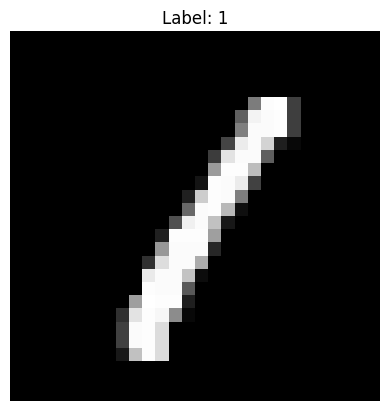

In [32]:
import matplotlib.pyplot as plt
import numpy as np

plt.imshow(train_images[3].reshape(28, 28), cmap='gray')
plt.title(f'Label: {train_labels[3]}')
plt.axis('off')
plt.show()

Network architecture

In [12]:
import keras
from keras import layers

model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax") 
    ]    
)

Compilation step

In [13]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Preparing the image data

In [14]:
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255
test_images = test_images.reshape((10000, 28 * 28))
test_images = test_images.astype("float32") / 255

Fitting the model 

In [15]:
model.fit(train_images, train_labels, epochs=5, batch_size=128)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8672 - loss: 0.4709
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9655 - loss: 0.1171
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9794 - loss: 0.0717
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9855 - loss: 0.0500
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9902 - loss: 0.0358


Using the model to make predictions

In [16]:
test_digits = test_images[0:10]
predictions = model.predict(test_digits)
predictions[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


array([1.07466434e-07, 1.48613054e-07, 6.39129848e-06, 2.36314063e-05,
       4.89874497e-09, 1.76405294e-07, 2.70425765e-11, 9.99967635e-01,
       1.07226947e-06, 7.00572798e-07], dtype=float32)

Argument with the highest probability is the prediction made

In [17]:
predictions[0].argmax()

7

In [18]:
predictions[0][7]

0.99996763